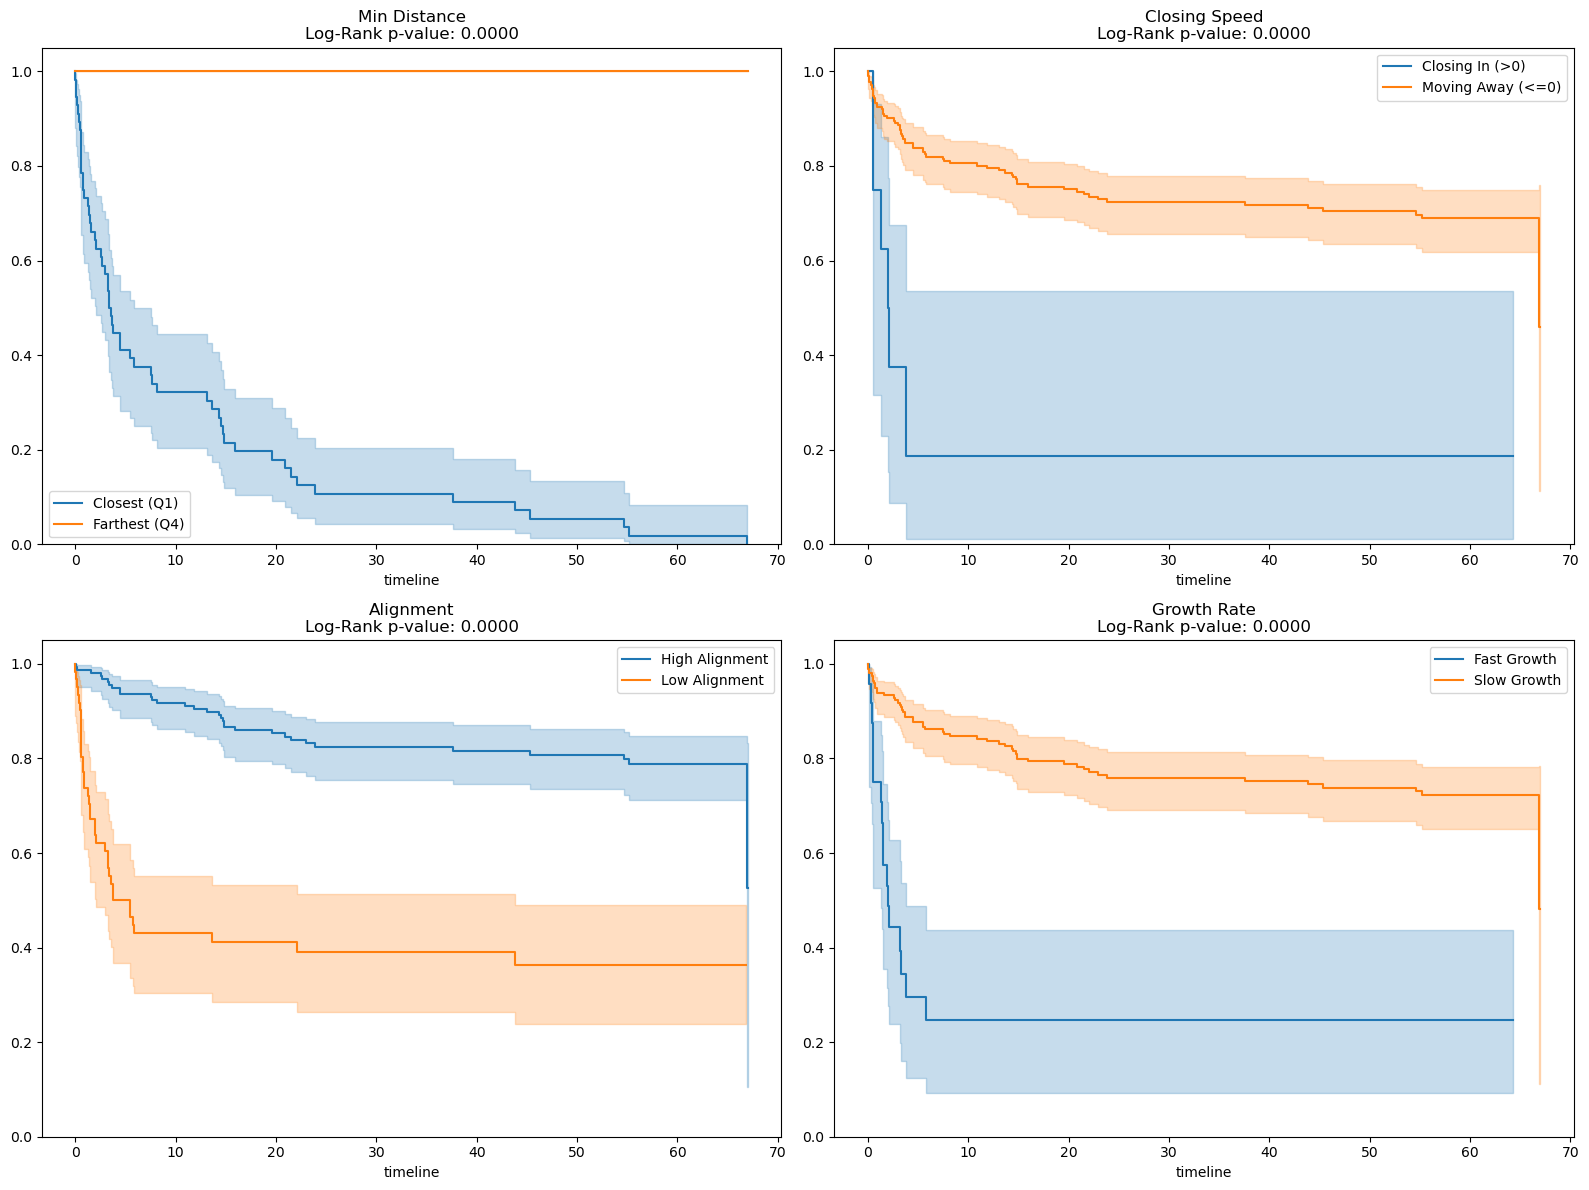

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install lifelines
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# 1. Load your dataset
file_path = "C:\\Users\\Anandhi\\Downloads\\WiDSWorldWide_GlobalDathon26\\train.csv"
df = pd.read_csv(file_path)

kmf = KaplanMeierFitter()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

def plot_and_test(data, group_col, labels, ax, title):
    # Fit and Plot
    for label, subset in labels.items():
        kmf.fit(subset['time_to_hit_hours'], subset['event'], label=label)
        kmf.plot_survival_function(ax=ax)
    
    # Log-Rank Test (Comparing the first two groups found)
    g1, g2 = list(labels.values())[0], list(labels.values())[1]
    results = logrank_test(g1['time_to_hit_hours'], g2['time_to_hit_hours'], 
                           event_observed_A=g1['event'], event_observed_B=g2['event'])
    
    ax.set_title(f"{title}\nLog-Rank p-value: {results.p_value:.4f}")
    ax.set_ylim(0, 1.05)

# --- A. dist_min quartile ---
q1, q4 = df['dist_min_ci_0_5h'].quantile([0.25, 0.75])
dist_labels = {
    'Closest (Q1)': df[df['dist_min_ci_0_5h'] <= q1],
    'Farthest (Q4)': df[df['dist_min_ci_0_5h'] >= q4]
}
plot_and_test(df, 'dist_min_ci_0_5h', dist_labels, axes[0], "Min Distance")

# --- B. closing_speed_mph ---
speed_labels = {
    'Closing In (>0)': df[df['closing_speed_m_per_h'] > 0],
    'Moving Away (<=0)': df[df['closing_speed_m_per_h'] <= 0]
}
plot_and_test(df, 'closing_speed_m_per_h', speed_labels, axes[1], "Closing Speed")

# --- C. alignment_abs ---
med_align = df['alignment_abs'].median()
align_labels = {
    'High Alignment': df[df['alignment_abs'] <= med_align],
    'Low Alignment': df[df['alignment_abs'] > med_align]
}
plot_and_test(df, 'alignment_abs', align_labels, axes[2], "Alignment")

# --- D. ag_rate_ha_per_h ---
med_growth = df['area_growth_rate_ha_per_h'].median()
growth_labels = {
    'Fast Growth': df[df['area_growth_rate_ha_per_h'] > med_growth],
    'Slow Growth': df[df['area_growth_rate_ha_per_h'] <= med_growth]
}
plot_and_test(df, 'area_growth_rate_ha_per_h', growth_labels, axes[3], "Growth Rate")

plt.tight_layout()
plt.show()
